In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("../results/Simulation_test.pkl", "rb") as f:
    loaded_data = pickle.load(f)

# Extract the parameters
params = loaded_data["parameters"]
history_biomass = loaded_data["history_biomass"]
history_elements = loaded_data["history_elements"]
history_biomass_grid = loaded_data["history_biomass_grid"]
history_spp_biomass = loaded_data["history_spp_biomass"]
history_spp_biomass_grid = loaded_data["history_spp_biomass_grid"]
history_spp_count = loaded_data["history_spp_count"]
N_SPP = loaded_data["N_SPP"]

# Now you can use them in your plots!
print(f"This simulation ran for {params['N_STEPS']} steps on a {params['H']}x{params['W']} grid.")
carrying_capacity = params["K_biomass"]
N_STEPS = params["N_STEPS"]

This simulation ran for 500 steps on a 100x100 grid.


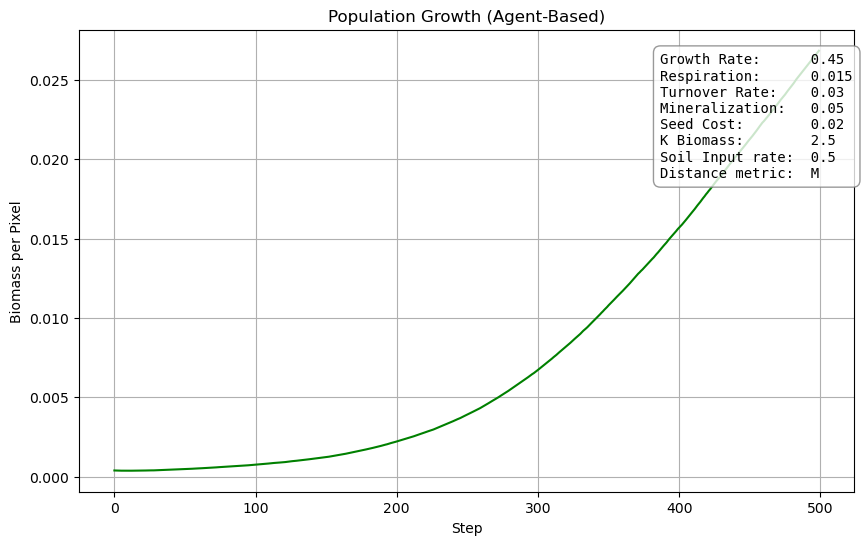

In [3]:
history_elements = np.array(history_elements)

params_text = (
    f"Growth Rate:      {params["growth_rate"]}\n"
    f"Respiration:      {params["respiration_rate"]}\n"
    f"Turnover Rate:    {params["turnover_rate"]}\n"
    f"Mineralization:   {params["mineralization_rate"]}\n"
    f"Seed Cost:        {params["seed_cost"]}\n"
    f"K Biomass:        {params["K_biomass"]}\n"
    f"Soil Input rate:  {params["soil_input_rate"]}\n"
    f"Distance metric:  M"
)


# Plot 1: Biomass Trajectory
plt.figure(figsize=(10, 6))
plt.plot(range(0, N_STEPS, 1), history_biomass, color='green')
plt.text(0.75, 0.95, params_text,
         transform=plt.gca().transAxes,  # Use relative coordinates (0-1)
         fontsize=10,
         verticalalignment='top',
         fontfamily='monospace',         # Monospace makes numbers align perfectly
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='white',
                   alpha=0.8,            # Semi-transparent background
                   edgecolor='gray'))
plt.xlabel("Step")
plt.ylabel("Biomass per Pixel")
plt.title("Population Growth (Agent-Based)")
plt.grid(True)
plt.show()

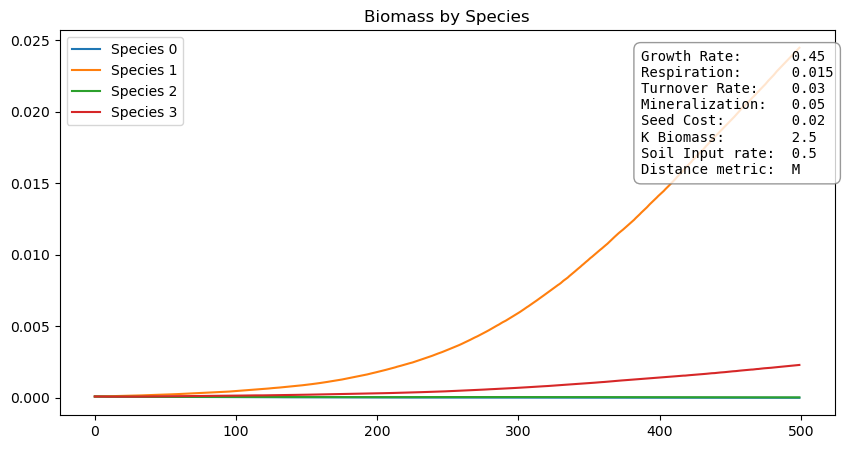

In [4]:
plt.figure(figsize=(10, 5))
for s_id in range(N_SPP):
    plt.plot(range(0, N_STEPS, 1), history_spp_biomass[s_id], label=f"Species {s_id}")


plt.text(0.75, 0.95, params_text,
         transform=plt.gca().transAxes,  # Use relative coordinates (0-1)
         fontsize=10,
         verticalalignment='top',
         fontfamily='monospace',         # Monospace makes numbers align perfectly
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='white',
                   alpha=0.8,            # Semi-transparent background
                   edgecolor='gray'))
plt.legend()
plt.title("Biomass by Species")
plt.show()

In [5]:
# Set global max to carrying capacity
global_max = 2.5

N_SPP = len(history_spp_biomass_grid)
num_frames = len(history_spp_biomass_grid[0])
H, W = np.array(history_spp_biomass_grid[0][0]).shape

# --- DEFINE COLORS FOR EACH SPECIES (RGB format) ---
# Add more colors to this list if you ever go beyond 6 species
SPECIES_COLORS = np.array([
    [255, 0, 0],    # Spp0: Pure Red
    [0, 255, 0],    # Spp1: Pure Green
    [0, 0, 255],    # Spp2: Pure Blue
    [255, 165, 0],  # Spp3: Orange
    [255, 0, 255],  # Spp4: Magenta
    [0, 255, 255]   # Spp5: Cyan
], dtype=np.float32)

# Ensure we don't try to pull more colors than we have defined
colors_to_use = SPECIES_COLORS[:N_SPP]

# --- Build the Video Array ---
# We use float32 first to allow proper math and blending without integer overflow
video_float = np.zeros((num_frames, H, W, 3), dtype=np.float32)

for i in range(num_frames):
    # Loop through each species dynamically
    for s_id in range(N_SPP):
        # 1. Get the grid and calculate intensity (0.0 to 1.0)
        grid = np.array(history_spp_biomass_grid[s_id][i])
        intensity = np.clip(grid / global_max, 0.0, 1.0)

        # 2. Add this species' color to the composite image
        # Shape of intensity is (H, W). We add an axis to make it (H, W, 1) so it broadcasts with the (3,) color array
        species_layer = intensity[..., np.newaxis] * colors_to_use[s_id]

        # 3. Additive blending: Just add the light together
        video_float[i] += species_layer

# Clip the final mathematical additions back to 0-255 and cast to uint8 for image rendering
video = np.clip(video_float, 0, 255).astype(np.uint8)

# --- Dynamic Title Generation ---
color_names = ["Red", "Green", "Blue", "Orange", "Magenta", "Cyan"]
title_legend = ", ".join([f"{color_names[s]}=Spp{s}" for s in range(N_SPP)])

# Render the video
fig = px.imshow(
    video,
    animation_frame=0,
    title=f"Multispecies Competition Blended ({title_legend})",
    labels={'animation_frame': 'Time Step'},
    width=1000,
    height=1000
)

# Remove the axis ticks and lines for a clean map look
fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_layout(margin=dict(l=10, r=10, t=50, b=10))

fig.show()

NameError: name 'px' is not defined

In [6]:
### GRID with Borders ###

# Set global max to carrying capacity
global_max = 2.5

num_frames = len(history_spp_biomass_grid[0])
H, W = np.array(history_spp_biomass_grid[0][0]).shape

# --- NEW: Create a 3x upscaled array ---
# Shape is now (Time, Height*3, Width*3, 3 color channels)
video = np.zeros((num_frames, H * 3, W * 3, 3), dtype=np.uint8)

# --- DRAW THE BORDERS ---
# Set every 3rd pixel to a dark gray [60, 60, 60] to create a grid fence around cells
video[:, 2::3, :, :] = 60  # Draw horizontal grid lines
video[:, :, 2::3, :] = 60  # Draw vertical grid lines

for i in range(num_frames):
    grid0 = np.array(history_spp_biomass_grid[0][i])
    grid1 = np.array(history_spp_biomass_grid[1][i])
    grid2 = np.array(history_spp_biomass_grid[2][i])

    # Scale the intensities to 0-255
    c0 = np.clip((grid0 / global_max) * 255, 0, 255)
    c1 = np.clip((grid1 / global_max) * 255, 0, 255)
    c2 = np.clip((grid2 / global_max) * 255, 0, 255)

    # --- MAP TO SUB-CELLS INSIDE THE BORDERS ---
    # Top-Left of the cell: Species 0 (Red)
    video[i, 0::3, 0::3, 0] = c0

    # Top-Right of the cell: Species 1 (Green)
    video[i, 0::3, 1::3, 1] = c1

    # Bottom-Left of the cell: Species 2 (Blue)
    video[i, 1::3, 0::3, 2] = c2

    # The Bottom-Right (1::3, 1::3) stays black [0,0,0] for contrast!

# Render the fenced video
fig = px.imshow(
    video,
    animation_frame=0,
    title="Biomass per Cell (Grid boxes = 1 Cell | Red=Spp0, Green=Spp1, Blue=Spp2)",
    labels={'animation_frame': 'Time Step'},
    width=1000,   # <--- ADDED: Width in pixels
    height=1000   # <--- ADDED: Height in pixels
)

# Remove the axis ticks since we drew our own grid
fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)

# Optional: You can also reduce the margins if you want the image to fill more of the frame
fig.update_layout(margin=dict(l=10, r=10, t=50, b=10))

fig.show()


NameError: name 'px' is not defined

In [69]:
import plotly.graph_objects as go

# We record data every 10 steps (based on `t % 10 == 0` in your loop)
x_steps = np.arange(0, N_STEPS, 10)

fig = go.Figure()

# Define specific colors for each species (Red, Green, Blue, Orange)
colors = ['red', 'green', 'blue', 'orange']

for s_id in range(N_SPP):
    fig.add_trace(go.Scatter(
        x=x_steps,
        y=history_spp_fitness[s_id],
        mode='lines', # Use 'lines+markers' if you want dots on every data point
        name=f'Species {s_id}',
        line=dict(color=colors[s_id], width=3)
    ))

fig.update_layout(
    title="Average Niche Fitness per Species Over Time",
    xaxis_title="Simulation Step",
    yaxis_title="Average Fitness (0 = Dead, 1 = Perfect Match)",
    yaxis=dict(range=[-0.05, 1.05]), # Lock Y-axis from 0 to 1
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

NameError: name 'history_spp_fitness' is not defined